In [1]:
# import data files from drive
import os
import pandas as pd
from IPython.display import clear_output
!pip install gdown

!gdown --id 1-4OxIB2mcBxzb_Po-RzTAhBkeGjuABjY -O movies.csv
!gdown --id 1ThHgrGgvLE45wKYac9R9lQb_PK5tctE0 -O movies_data.db
clear_output()

# SQL: Production Companies and Budget

In [2]:
# import necessary packages
import numpy as np
import sqlite3 as sql

In [3]:
# connect to the database
db = sql.connect('movies_data.db')

In [4]:
# view all tables in the database
pd.read_sql('SELECT * FROM sqlite_master', db)

,type,name,tbl_name,rootpage,sql
0,table,movies,movies,5357,"CREATE TABLE ""movies"" (\n""movie_id"" INTEGER,\n..."
1,table,genres,genres,2,"CREATE TABLE ""genres"" (\n""genre_id"" INTEGER,\n..."
2,table,countries,countries,400,"CREATE TABLE ""countries"" (\n""country_id"" INTEG..."
3,table,companies,companies,97871,"CREATE TABLE ""companies"" (\n""company_id"" INTEG..."
4,table,movie_genres,movie_genres,3,"CREATE TABLE ""movie_genres"" (\n""movie_id"" INTE..."
5,table,movie_countries,movie_countries,983,"CREATE TABLE ""movie_countries"" (\n""movie_id"" I..."
6,table,movie_companies,movie_companies,3155,"CREATE TABLE ""movie_companies"" (\n""movie_id"" I..."


In [5]:
# take a look at companies table
pd.read_sql('SELECT * FROM companies', db)

,company_id,company
0,1,Avi Chai Film Foundation
1,2,Grand Angle Productions
2,3,S.A.
3,4,"""A ME AND YOU MOTION PICTURE"""
4,5,"""DIA"" Productions GmbH & Co. KG"
...,...,...
156564,156565,한국 영화독립제작소 물결
156565,156566,한국독립애니메이션협회
156566,156567,한맥문화
156567,156568,핸드메이드 스튜디오


In [6]:
# take a look at the movie_companies table
pd.read_sql('SELECT * FROM movie_companies', db)

,movie_id,company_id
0,4520010,77761
1,4520010,131551
2,4520010,147375
3,4520011,77761
4,4520011,131551
...,...,...
712201,5568571,6905
712202,5568572,6905
712203,5568573,124627
712204,5568583,60615


In [7]:
# take a look at the movies table
pd.read_sql('SELECT * FROM movies', db)

,movie_id,title,vote_average,vote_count,status,release_date,revenue,adult,budget,imdb_id,original_language,original_title,overview,popularity,genres,production_companies,production_countries,spoken_languages
0,4520010,Inception,8.364,34495,Released,7/15/2010,825532764,0,160000000,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili"
1,4520011,Interstellar,8.417,32571,Released,11/5/2014,701729206,0,165000000,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English
2,4520012,The Dark Knight,8.512,30619,Released,7/16/2008,1004558444,0,185000000,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin"
3,4520013,Avatar,7.573,29815,Released,12/15/2009,2923706026,0,237000000,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish"
4,4520014,The Avengers,7.710,29166,Released,4/25/2012,1518815515,0,220000000,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,5568580,Master of Demon Subjugation,0.000,0,Released,1/9/2020,0,0,0,None,zh,降魔大师,In order to save the border town Tianhe from e...,0.600,None,None,China,Mandarin
1048571,5568581,Storybook Classics: Ivanhoe,0.000,0,Released,1/1/1988,0,0,0,None,en,Storybook Classics: Ivanhoe,Wilfred of Ivanhoe is a loyal knight to King R...,0.600,None,None,None,None
1048572,5568582,Screen Flicker,0.000,0,Released,1/1/2012,0,0,0,None,en,Screen Flicker,SCREEN FLICKER re-stages the flatness of the c...,0.600,None,None,None,None
1048573,5568583,Chamber of Whores 2: Pornworld,0.000,0,Released,5/22/1999,0,1,0,None,en,Chamber of Whores 2: Pornworld,"Escape From Pornworld ""I'm here Stan. I have ...",0.841,None,Heatwave,None,None


In [8]:
# create a view with company ID, company name, and movie ID to support table joins later
db.execute('''CREATE VIEW companies_and_movies (
                 company_id, company_name, movie_id
              ) AS
              SELECT comp.company_id, comp.company, mov_comp.movie_id
               FROM companies as comp
               JOIN movie_companies as mov_comp
               ON comp.company_id = mov_comp.company_id;''')
db.commit()

In [9]:
# take a look at the resulting view
pd.read_sql("SELECT * FROM companies_and_movies ORDER BY movie_id LIMIT 5 ", db)

,company_id,company_name,movie_id
0,77761,Legendary Pictures,4520010
1,131551,Syncopy,4520010
2,147375,Warner Bros. Pictures,4520010
3,77761,Legendary Pictures,4520011
4,82132,Lynda Obst Productions,4520011


In [10]:
# create a table that matches up each movie, budget, and company name
pd.read_sql('''SELECT m.movie_id, m.title, m.budget, c.company_name
               FROM movies as m
               LEFT JOIN companies_and_movies as c
               ON m.movie_id = c.movie_id
               LIMIT 5''', db)

,movie_id,title,budget,company_name
0,4520010,Inception,160000000,Legendary Pictures
1,4520010,Inception,160000000,Syncopy
2,4520010,Inception,160000000,Warner Bros. Pictures
3,4520011,Interstellar,165000000,Legendary Pictures
4,4520011,Interstellar,165000000,Lynda Obst Productions


In [11]:
db.execute('DROP VIEW IF EXISTS companies_movies_and_budget')
db.commit()

In [12]:
# create a view with movie_id, title, vote average, budget, revenue, release date, and company name to support analysis
# filter for only observations with budget greater than 10000, revenue greater than 10000, and not missing production company name
db.execute('''CREATE VIEW companies_movies_and_budget (
                movie_id, title, vote_average, budget, revenue, release_date, company_name
              ) AS
              SELECT m.movie_id, m.title, m.vote_average, m.budget, m.revenue, m.release_date, c.company_name
               FROM movies as m
               LEFT JOIN companies_and_movies as c
               ON m.movie_id = c.movie_id
               WHERE (m.budget >= 10000) & (m.revenue >=10000) & (c.company_name IS NOT NULL);''')
db.commit()

In [13]:
# take a look at the resulting view
pd.read_sql("SELECT * FROM companies_movies_and_budget LIMIT 5 ", db)

,movie_id,title,vote_average,budget,revenue,release_date,company_name
0,4520010,Inception,8.364,160000000,825532764,7/15/2010,Legendary Pictures
1,4520010,Inception,8.364,160000000,825532764,7/15/2010,Syncopy
2,4520010,Inception,8.364,160000000,825532764,7/15/2010,Warner Bros. Pictures
3,4520011,Interstellar,8.417,165000000,701729206,11/5/2014,Legendary Pictures
4,4520011,Interstellar,8.417,165000000,701729206,11/5/2014,Lynda Obst Productions


In [14]:
# check for missing values after pre-processing
pd.read_sql("SELECT * FROM companies_movies_and_budget WHERE company_name IS NULL ", db)

,movie_id,title,vote_average,budget,revenue,release_date,company_name


In [15]:
# aggregate by company_name to get total budget, creating a dataframe for data analysis
companies_and_total_budgets = pd.read_sql('''SELECT company_name, sum(budget) as total_budget, avg(vote_average) as average_movie_rating
               FROM companies_movies_and_budget
               WHERE (company_name IS NOT NULL) & (vote_average IS NOT NULL)
               GROUP BY company_name
               HAVING total_budget > 0
               ORDER BY total_budget DESC''', db)
companies_and_total_budgets.head()

,company_name,total_budget,average_movie_rating
0,Warner Bros. Pictures,31009249975,6.456860
1,Universal Pictures,23422046307,6.447181
2,Paramount,21150448479,6.491607
3,Columbia Pictures,20901430753,6.435200
4,20th Century Fox,18743316054,6.413298


In [16]:
companies_and_total_budgets.describe()

,total_budget,average_movie_rating
count,9.869000e+03,9869.000000
mean,8.943244e+07,6.234153
std,6.428759e+08,1.367710
min,1.000000e+04,0.000000
25%,3.500000e+06,5.854000
50%,1.300000e+07,6.403000
75%,4.300000e+07,6.938000
max,3.100925e+10,10.000000


# Visualizations

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
# read data into a dataframe
companies_movies_and_budget = pd.read_sql("SELECT * FROM companies_movies_and_budget", db)
companies_movies_and_budget.head()

,movie_id,title,vote_average,budget,revenue,release_date,company_name
0,4520010,Inception,8.364,160000000,825532764,7/15/2010,Legendary Pictures
1,4520010,Inception,8.364,160000000,825532764,7/15/2010,Syncopy
2,4520010,Inception,8.364,160000000,825532764,7/15/2010,Warner Bros. Pictures
3,4520011,Interstellar,8.417,165000000,701729206,11/5/2014,Legendary Pictures
4,4520011,Interstellar,8.417,165000000,701729206,11/5/2014,Lynda Obst Productions


In [19]:
# get a quick statistical summary of the budget column
companies_movies_and_budget['budget'].describe()

count    2.990400e+04
mean     2.951474e+07
std      3.995213e+07
min      1.000000e+04
25%      5.000000e+06
50%      1.500000e+07
75%      3.600000e+07
max      4.600000e+08
Name: budget, dtype: float64

### Companies and Total Budgets

In [20]:
# identify companies with highest total budgets
companies_total_budgets = companies_movies_and_budget.groupby("company_name").sum("budget").drop(['movie_id', 'vote_average'], axis = 'columns')

top_total_budgets = companies_total_budgets.sort_values(by='budget', ascending=False).iloc[0:100, :]
top_total_budgets

,budget,revenue
company_name,,
Warner Bros. Pictures,31009249975,80081736522
Universal Pictures,23422046307,76267870665
Paramount,21150448479,62721271839
Columbia Pictures,20901430753,59185619397
20th Century Fox,18743316054,63082592638
...,...,...
Bad Hat Harry Productions,1333000000,3170722318
Sony Pictures Animation,1316000000,5332454091
Intermedia Films,1305032673,1820977177


### Total Budgets in 2023

In [21]:
# first, do some pre-processing to extract the release year
# load in the data
data = pd.read_sql("SELECT * FROM companies_movies_and_budget", db)

In [22]:
# examine where the release_date is missing
data[data['release_date'].isna()]

,movie_id,title,vote_average,budget,revenue,release_date,company_name
29158,4708730,Blood Line,10.0,60000,100000,None,Smol Cat Films
29305,4765620,Mysterious Brother,10.0,300000,400000,None,ActOn Productions
29315,4770932,Unreal,8.0,20000,50000,None,Red Right Hand
29316,4770932,Unreal,8.0,20000,50000,None,Sevens Film Corporation
29358,4783466,Troglejuice,10.0,56950000,756000000,None,Trog Enterprises
...,...,...,...,...,...,...,...
29831,5422477,Mert'in Ütü Masası,0.0,420000,1280000,None,Doringle
29837,5435293,Goofer’s Brush,0.0,100000,40000000,None,Chuck and Karl
29840,5444474,The Swarm,0.0,1000000,3000000,None,Synergy
29863,5493699,You Before US,0.0,3000000,100000000,None,قصة عشق


In [23]:
# drop missing release_date
data_no_missing = data.copy()
data_no_missing = data_no_missing[data_no_missing['release_date'].notna()]

In [24]:
# check for missing
sum(data_no_missing['release_date'].isna())

0

In [25]:
# extract the release year and release month and create new columns
data_no_missing['release_year'] = data_no_missing['release_date'].str.extract(pat = "([0-9]{4}$)").astype(int)
data_no_missing['release_month'] = data_no_missing['release_date'].str.extract(pat = "^([0-9]{1,2})").astype(int)
data_no_missing.head()

,movie_id,title,vote_average,budget,revenue,release_date,company_name,release_year,release_month
0,4520010,Inception,8.364,160000000,825532764,7/15/2010,Legendary Pictures,2010,7
1,4520010,Inception,8.364,160000000,825532764,7/15/2010,Syncopy,2010,7
2,4520010,Inception,8.364,160000000,825532764,7/15/2010,Warner Bros. Pictures,2010,7
3,4520011,Interstellar,8.417,165000000,701729206,11/5/2014,Legendary Pictures,2014,11
4,4520011,Interstellar,8.417,165000000,701729206,11/5/2014,Lynda Obst Productions,2014,11


In [26]:
# find the most recent year that we have data for
data_no_missing['release_year'].sort_values(ascending=False)

29624    2024
29345    2024
29347    2024
29349    2024
29350    2024
         ... 
26242    1915
17884    1915
28782    1915
29734    1914
29755    1914
Name: release_year, Length: 29833, dtype: int64

In [27]:
# notice that the data for 2024 doesn't seem complete -- only has up to July
data_2024 = data_no_missing[data_no_missing['release_year'] == 2024]
data_2024.sort_values('release_month')

,movie_id,title,vote_average,budget,revenue,release_date,company_name,release_year,release_month
29603,5056270,Birth of A Savage,0.0,110000,130000,1/17/2024,Coattail Entertainment,2024,1
29604,5056270,Birth of A Savage,0.0,110000,130000,1/17/2024,Reel Riches Pictures,2024,1
29342,4782606,Mayan Trance to God's Immortality Being,10.0,10000,10000,1/5/2024,Austmon,2024,1
29394,4786021,Venice 2024 Journey Australia,9.0,10000,10000,1/19/2024,Austmon,2024,1
29626,5089310,This Is It,0.0,11000,21000,2/14/2024,Reverb Nation,2024,2
29625,5089310,This Is It,0.0,11000,21000,2/14/2024,Mambo Ya Town Huezi Elewa,2024,2
29610,5062713,Cold Blooded Love,0.0,50000,55000,4/10/2024,Aron Film Baris Ozgur,2024,4
29611,5062713,Cold Blooded Love,0.0,50000,55000,4/10/2024,Baris Ozgur,2024,4
29612,5062713,Cold Blooded Love,0.0,50000,55000,4/10/2024,O My God Films Llc,2024,4
29362,4783793,The Stalked,10.0,40000,44483,4/5/2024,Korvinrular,2024,4


In [28]:
# filter for release_year == 2023
# notice that we now have movies from January to December, the full year
data_2023 = data_no_missing[data_no_missing['release_year'] == 2023]
data_2023.sort_values('release_month')

,movie_id,title,vote_average,budget,revenue,release_date,company_name,release_year,release_month
26530,4547306,Deep Sea,7.100,28700000,136090000,1/22/2023,Horgos Coloroom Pictures,2023,1
12635,4523804,Operation Fortune: Ruse de Guerre,6.582,50000000,37846713,1/4/2023,Toff Guy Films,2023,1
14296,4524497,Winnie the Pooh: Blood and Honey,5.492,100000,5200000,1/27/2023,ITN Studios,2023,1
14297,4524497,Winnie the Pooh: Blood and Honey,5.492,100000,5200000,1/27/2023,Jagged Edge Productions,2023,1
24688,4537437,Pathaan,6.607,63000000,112000000,1/25/2023,Yash Raj Films,2023,1
...,...,...,...,...,...,...,...,...,...
29379,4784873,Pattaya Explicit,10.000,10000,10000,11/9/2023,Austmon,2023,11
29654,5112074,November,0.000,10000,100000,12/4/2023,Dark Rain Entertainment,2023,12
29606,5057229,THE ELF,0.000,20000,30000,12/15/2023,Rearick Film Studios,2023,12
29368,4784338,Hafiz & Friends Recap: This Is Why We Can Have...,9.000,576749,689365,12/16/2023,SOUR+ Entertainment Inc,2023,12


In [29]:
# group by company and then sum budgets
total_budgets_2023 = data_2023[['company_name', 'budget']].groupby('company_name').sum().sort_values('budget', ascending = False)
total_budgets_2023

,budget
company_name,
Paramount,800000000
Universal Pictures,793500000
Walt Disney Pictures,607800000
Warner Bros. Pictures,594000000
DC Films,545000000
...,...
8th Dimension,20000
ERO Picture Company,15000
Realionaire,15000


In [30]:
# quick statistical summary of year 2023 total budgets
total_budgets_2023['budget'].describe()

count    3.340000e+02
mean     6.613677e+07
std      1.114651e+08
min      1.000000e+04
25%      6.750000e+06
50%      2.800000e+07
75%      7.000000e+07
max      8.000000e+08
Name: budget, dtype: float64

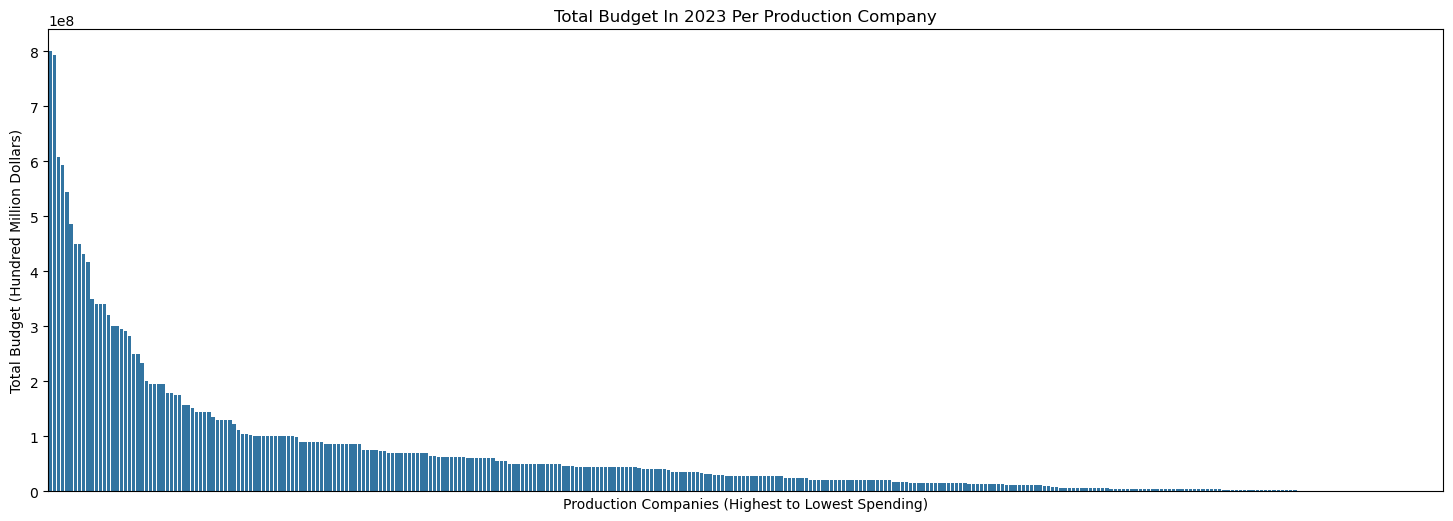

In [31]:
# plot the total budgets for each company

plt.figure(figsize=(18, 6))

plt.title("Total Budget In 2023 Per Production Company")
plt.xlabel("Production Companies (Highest to Lowest Spending)")
plt.ylabel("Total Budget (Hundred Million Dollars)")

sns.barplot(x='company_name', y='budget', data=total_budgets_2023)

plt.xticks([])
plt.show()

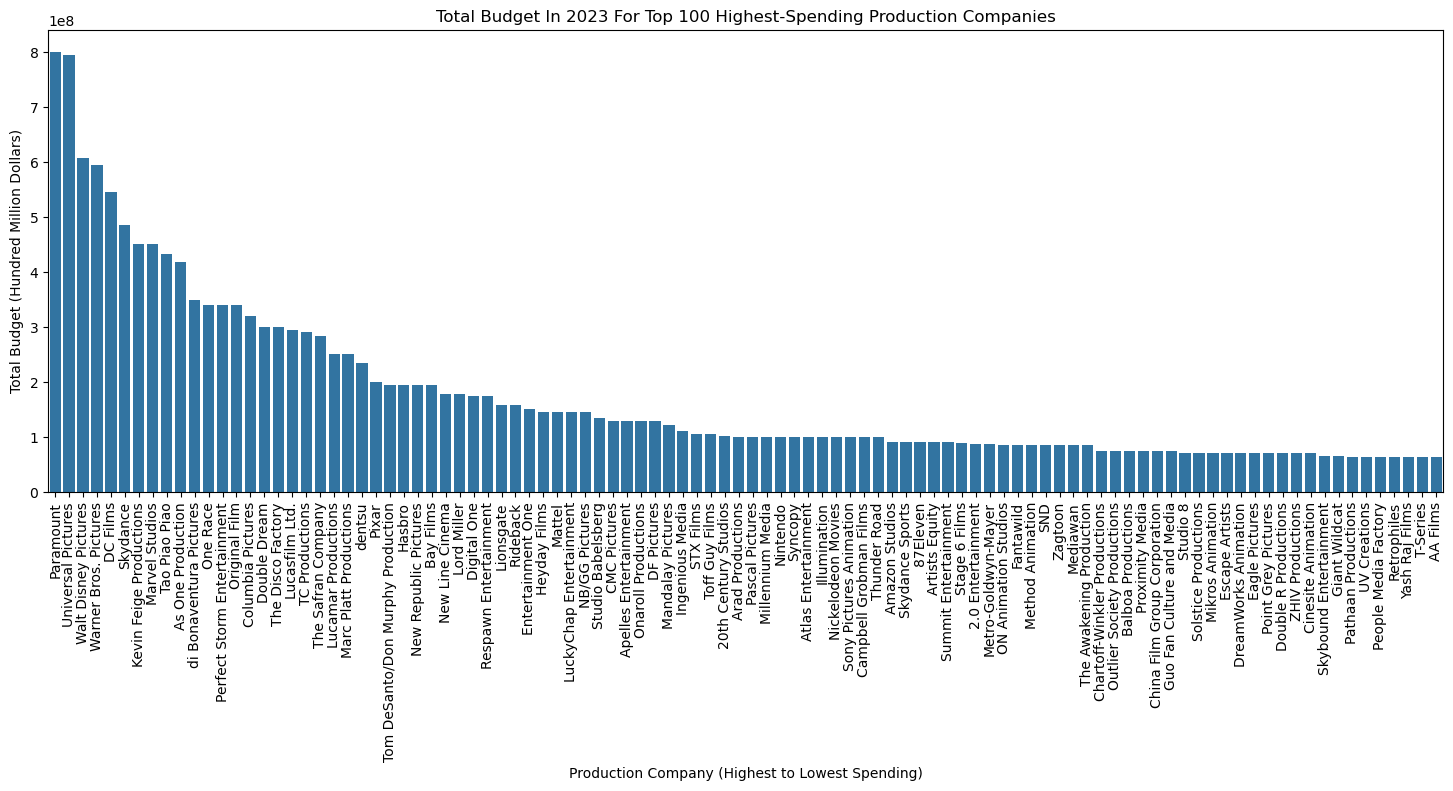

In [32]:
# create a visualization of the top 100 highest-spending production companies
total_budgets_2023_top_100 = total_budgets_2023.iloc[0:100, :]

plt.figure(figsize=(18, 6))

plt.title("Total Budget In 2023 For Top 100 Highest-Spending Production Companies")
plt.xlabel("Production Company (Highest to Lowest Spending)")
plt.ylabel("Total Budget (Hundred Million Dollars)")

sns.barplot(x='company_name', y='budget', data=total_budgets_2023_top_100)
plt.xticks(rotation=90)

plt.show()

### Animated Visualization

In [33]:
import imageio

In [34]:
# get the maximum total budget spent in a year by a production company
data_no_missing_grouped = data_no_missing.groupby(['release_year', 'company_name']).sum()
max_total_budget = max(data_no_missing_grouped['budget'])
max_total_budget

1390600000

In [35]:
# set the bins so that the figures for each year are consistent
bins = np.linspace(0, max_total_budget, 50)

In [36]:
len(bins)

50

In [37]:
# note: this function heavily referenced code from lecture

def render_frame(year):
    """Render a single frame (plot) in an animated visualization.

    Adapted from: https://ndres.me/post/matplotlib-animated-gifs-easily/
    """
    # Create a matplotlib figure to plot into.
    fig = plt.figure(figsize=(10, 6))

    # -------------------- Visualization Code

    data_subset = data_no_missing[data_no_missing["release_year"] == year]
    year_data = data_subset.groupby('company_name').sum()
    ax = sns.histplot(x='budget', data=year_data, bins = bins, stat='percent')
    plt.xlim(bins[0], bins[-1])
    plt.ylim(0, 100)

    ax.set_title(str(year))
    ax.set_xlabel("Total Budget (Billions of Dollars)")
    ax.set_ylabel("Percent of Companies")
    plt.xticks(rotation=90)

    # -------------------- End Visualization Code

    # Draw the figure and then convert it to a Numpy array.
    fig.canvas.draw()

    image = np.asarray(fig.canvas.buffer_rgba())

    # image = np.frombuffer(fig.canvas.tostring_argb(), dtype="uint8")
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (4,))

    # Close the matplotlib figure (we're done with it)
    plt.close()
    return image

In [38]:
# get a list of the years in our dataset
years = np.sort(data_no_missing["release_year"].unique())

In [39]:
years

array([1914, 1915, 1916, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925,
       1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936,
       1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947,
       1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958,
       1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
       1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [40]:
# create a list of the 50 most recent years in our dataset
last_50_years = years[-51:-1]

In [41]:
last_50_years

array([1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984,
       1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023])

In [42]:
# create plots for each of the 50 most recent years
plots = [render_frame(y) for y in last_50_years]

In [43]:
len(last_50_years)

50

In [44]:
len(plots)

50

In [45]:
# save the list of images as a GIF file
imageio.mimsave("yearly_budgets.gif", plots, fps = 2, loop = 0)

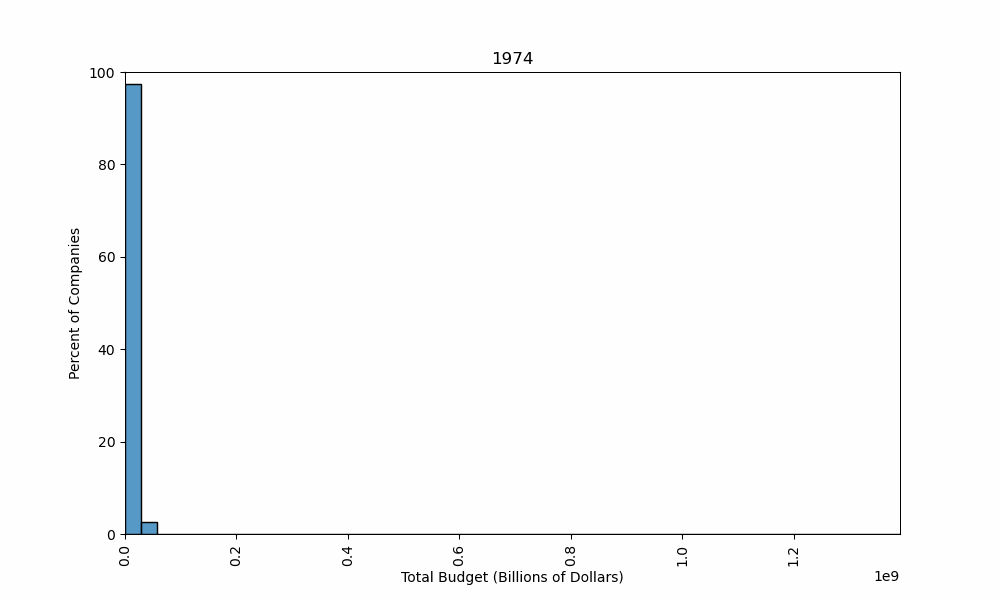

In [46]:
# display the GIF
from IPython.display import Image, display

display(Image(filename="yearly_budgets.gif"))

### Movies With Highest Budget

In [47]:
# sort the data by budget in descending order to see which movies had highest budget
sorted_companies_movies_and_budget = companies_movies_and_budget.sort_values(by=['budget'], ascending = False).reset_index().drop('index', axis='columns')
sorted_companies_movies_and_budget

,movie_id,title,vote_average,budget,revenue,release_date,company_name
0,4520292,Avatar: The Way of Water,7.654,460000000,2320250281,12/14/2022,20th Century Studios
1,4520292,Avatar: The Way of Water,7.654,460000000,2320250281,12/14/2022,Lightstorm Entertainment
2,4550224,Lost in the Stars,6.330,417549000,334039200,6/22/2023,Tao Piao Piao
3,4550224,Lost in the Stars,6.330,417549000,334039200,6/22/2023,As One Production
4,4520163,Pirates of the Caribbean: On Stranger Tides,6.538,379000000,1045713802,5/15/2011,Moving Picture Company
...,...,...,...,...,...,...,...
29899,4767118,Titanic Tits: Rural Cosplayer (Age 19) With A ...,8.000,10000,201187,3/19/2021,All Japan Kameko Cooperative
29900,4908008,探险旅行,0.000,10000,10000,8/31/2017,BIRAY DALKIRAN DFGS AMERICA
29901,4673355,Vespiary,6.700,10000,10000,3/20/2018,khane film
29902,4909641,Double Face,0.000,10000,200000,3/17/1997,Sameba


In [48]:
def get_top_companies_count(percent):
  '''A function that returns a DataFrame of the companies that produced the top [percent] percent most
    expensive movies and the number of such movies produced by each company and percent of such movies produced by each company'''
  # calculate % of the total number of movies (after filtering)
  percentage = round(companies_movies_and_budget.shape[0] * percent)

  # create a dataframe with the movies in the top [percent] percentile of budget
  top_pct_unagg = sorted_companies_movies_and_budget.iloc[0:percentage, :]

  top_pct_by_comp_count = top_pct_unagg.groupby('company_name').count()
  top_pct_by_comp_count['percent'] = top_pct_by_comp_count['movie_id']/np.sum(top_pct_by_comp_count['movie_id'])

  return top_pct_by_comp_count.sort_values(by='movie_id', ascending = False)

In [49]:
def get_top_companies(percent):
  '''A function that returns a DataFrame of the companies that produced the top [percent] percent most
  expensive movies and the total budget of those companies and the percent of each company's budget relative to total budgets'''
  # calculate % of the total number of movies (after filtering)
  percentage = round(companies_movies_and_budget.shape[0] * percent)

  # create a dataframe with the movies in the top [percent] percentile of budget
  top_pct_unagg = sorted_companies_movies_and_budget.iloc[0:percentage, :]

  top_pct_by_company = top_pct_unagg.groupby('company_name').sum('budget').sort_values('budget', ascending = False)
  top_pct_by_company['percent'] = top_pct_by_company['budget']/np.sum(top_pct_by_company['budget'])

  return top_pct_by_company.sort_values(by='percent', ascending = False)

In [50]:
# create a dataframe that contains the companies that produced movies that were in the top 0.5% for budget
df1 = get_top_companies(0.005)
len(df1)

76

In [51]:
# look at the top contributors to the most expensive movies
df1.head()

,movie_id,vote_average,budget,revenue,percent
company_name,,,,,
Warner Bros. Pictures,49723680,76.755,2845000000,8763896549,0.073248
Marvel Studios,40682464,67.035,2499000000,12292124574,0.064340
Walt Disney Pictures,40685368,60.661,2369000000,6591724573,0.060993
Metro-Goldwyn-Mayer,22601457,36.153,1245000000,4590350972,0.032054
Jerry Bruckheimer Films,18081285,26.514,1124000000,3063138215,0.028939


In [52]:
# quick statistical summary of the proportion each company contributed to the most expensive movies
df1['percent'].describe()

count    76.000000
mean      0.013158
std       0.012480
min       0.005381
25%       0.006353
50%       0.009256
75%       0.014160
max       0.073248
Name: percent, dtype: float64

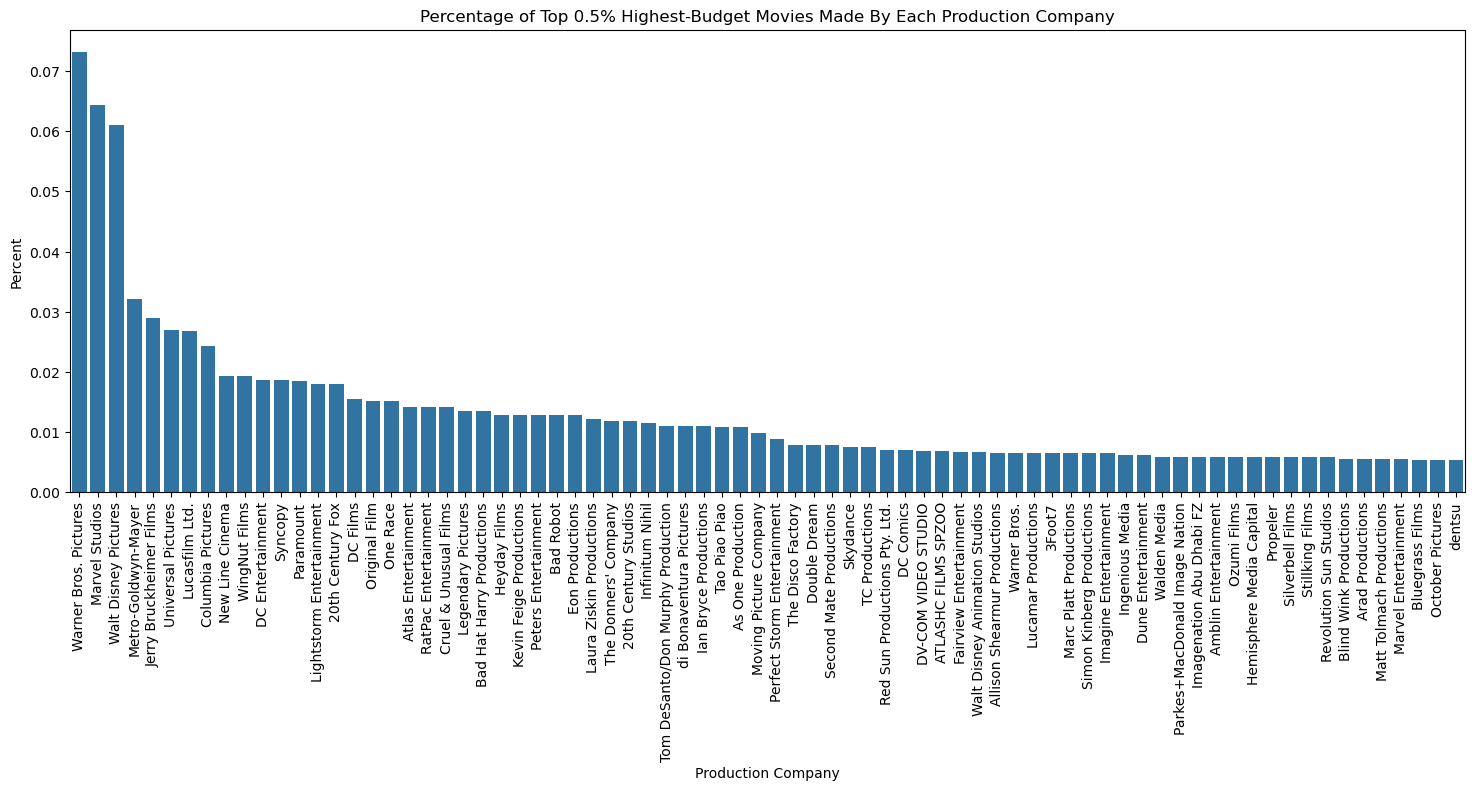

In [53]:
# create figure for report: percentage of top 0.5% highest-budget movies made by each production company
plt.figure(figsize=(18, 6))
plt.title("Percentage of Top 0.5% Highest-Budget Movies Made By Each Production Company")
plt.xlabel("Production Company")
plt.ylabel("Percent")
sns.barplot(x= "company_name", y = "percent", data = df1)
plt.xticks(rotation=90)
plt.show()